# Leistungsnachweis

- **Name:** Timo Rolf
- **Matriculation Number:** 22308350
- **Chosen language:** English
- **Corpus Name and Description:** English Wikipedia XML Corpus (Abstracts). This corpus contains the abstracts of all articles from the English Wikipedia, structured as an XML file, making it perfect for natural language processing tasks.
- **Corpus Download URL:** [https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-abstract1.xml.gz](https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-abstract1.xml.gz)

**Note for the professor:** If you choose not to use the automated download cell below, please ensure you manually extract the `.gz` file so that `enwiki-latest-abstract1.xml` is present in the directory!

---

## Solutions to the Task List

*(Solutions will be completed below)*

In [4]:
import os
import urllib.request
import gzip
import shutil

DOWNLOAD = True
# Using a stable, archived URL since latest abstracts are discontinued
corpus_url = 'https://archive.org/download/enwiki-20210820/enwiki-20210820-abstract1.xml.gz'
corpus_gz = 'enwiki-20210820-abstract1.xml.gz'
corpus_xml = 'enwiki-20210820-abstract1.xml'

if DOWNLOAD:
    if not os.path.exists(corpus_xml):
        if not os.path.exists(corpus_gz):
            print(f"Downloading {corpus_gz}...")
            try:
                req = urllib.request.Request(corpus_url, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req) as response, open(corpus_gz, 'wb') as out_file:
                    out_file.write(response.read())
                print(f"Successfully downloaded {corpus_gz}")
            except Exception as e:
                print(f"Failed to download {corpus_gz}: {e}")
        
        if os.path.exists(corpus_gz):
            print(f"Extracting {corpus_gz} to {corpus_xml}...")
            with gzip.open(corpus_gz, 'rb') as f_in:
                with open(corpus_xml, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            print("Extraction complete!")
            os.remove(corpus_gz)
            print(f"Deleted the compressed file {corpus_gz} as it is no longer needed.")
    else:
        print(f"{corpus_xml} already exists in the directory. No download/extraction necessary.")
else:
    print("DOWNLOAD is set to False. Skipping download step.")

Successfully downloaded enwiki-20210820-abstract1.xml.gz
Extracting enwiki-20210820-abstract1.xml.gz to enwiki-20210820-abstract1.xml...


Extraction complete!
Deleted the compressed file enwiki-20210820-abstract1.xml.gz as it is no longer needed.


## Preprocessing XML to Plain Text

The raw XML dataset is quite massive and contains a lot of metadata. We only want to train/evaluate our models and analyses on the actual text content of the abstracts. Therefore, we parse the large `.xml` file iteratively (to save memory) and extract solely the text within `<abstract>` tags into a neat, cleaned `.txt` file.

In [5]:
import os
import xml.etree.ElementTree as ET
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

corpus_xml = 'enwiki-20210820-abstract1.xml'
corpus_txt = 'enwiki-20210820-abstract1.txt'

if os.path.exists(corpus_xml):
    if not os.path.exists(corpus_txt):
        print(f"Extracting abstracts from {corpus_xml} to {corpus_txt}...")
        
        file_size = os.path.getsize(corpus_xml)
        
        with open(corpus_txt, 'w', encoding='utf-8') as f_out:
            # We wrap the file read stream with tqdm so it tracks the bytes read out of the total file size
            # instead of counting iterating nodes without knowing the total length.
            with tqdm.wrapattr(open(corpus_xml, 'rb'), "read", total=file_size, desc="Parsing XML") as f_in:
                context = ET.iterparse(f_in, events=('end',))
                
                # The structure features <abstract> tags inside <doc> tags.
                for event, elem in context:
                    if elem.tag == 'abstract':
                        if elem.text:
                            text = elem.text.strip()
                            # Some abstracts are technically empty or start with formatting
                            if text and not text.startswith('|'):
                                f_out.write(text + '\n')
                    # clear() helps reduce memory consumption while iteratively parsing
                    elem.clear()
        
        print(f"Extraction successful! Clean dataset saved at: {corpus_txt}")
    else:
        print(f"Cleaned dataset '{corpus_txt}' already exists. Skipping preprocessing.")
else:
    print(f"Source file '{corpus_xml}' not found. Did you download and extract it in the cell above?")

Extracting abstracts from enwiki-20210820-abstract1.xml to enwiki-20210820-abstract1.txt...


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [9]:
import os

corpus_txt = 'enwiki-20210820-abstract1.txt'

if os.path.exists(corpus_txt):
    size_bytes = os.path.getsize(corpus_txt)
    size_mb = size_bytes / (1024 * 1024)
    print(f"File '{corpus_txt}' found.")
    print(f"Size of cleaned dataset: {size_mb:.2f} MB")
else:
    print(f"File '{corpus_txt}' not found. Please run the preprocessing cell above.")

File 'enwiki-20210820-abstract1.txt' found.
Size of cleaned dataset: 49.57 MB


In [10]:
from nltk.corpus import PlaintextCorpusReader

corpus_file_txt = 'enwiki-20210820-abstract1.txt'

# NLTK expects a directory (root) and a regex or file name
corpus_root = '.'
print(f"Loading corpus {corpus_file_txt} via PlaintextCorpusReader...")
enwiki_corpus = PlaintextCorpusReader(corpus_root, corpus_file_txt)

# Print a bit of text to make sure it works!
print("\nSuccessfully loaded! Here are the first 20 words in the cleaned corpus:")
print(enwiki_corpus.words()[:20])

# You can now use enwiki_corpus.words() or enwiki_corpus.sents() for the rest of the exercises!

Loading corpus enwiki-20210820-abstract1.txt via PlaintextCorpusReader...

Successfully loaded! Here are the first 20 words in the cleaned corpus:
['Anarchism', 'is', 'a', 'political', 'philosophy', 'and', 'movement', 'that', 'is', 'sceptical', 'of', 'authority', 'and', 'rejects', 'all', 'involuntary', ',', 'coercive', 'forms', 'of']


# Task 4: Lexical Richness

In [11]:
text1 = enwiki_corpus.raw()
len(set(text1)) / len(text1)

7.884850515941128e-05

## Helper Plotting Function

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_frequency_distribution(fdist, title, xlabel, ylabel, limit=20, color='royalblue'):
    """
    Plots a beautiful, clean bar chart of a given NLTK FreqDist or a list of (element, count) tuples.
    Avoids scientific notation on the y-axis, adding comma separation instead.
    """
    # If a FreqDist is passed, get the most common elements.
    # Otherwise, assume it's already a list of tuples.
    if hasattr(fdist, 'most_common'):
        data = fdist.most_common(limit)
    else:
        data = fdist[:limit]
        
    labels, counts = zip(*data)
    
    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts, color=color, edgecolor='black', alpha=0.8)
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=12, labelpad=10)
    plt.ylabel(ylabel, fontsize=12, labelpad=10)
    
    # Format the y-axis to display full numbers with commas instead of scientific notation
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Task 5: Character Distribution

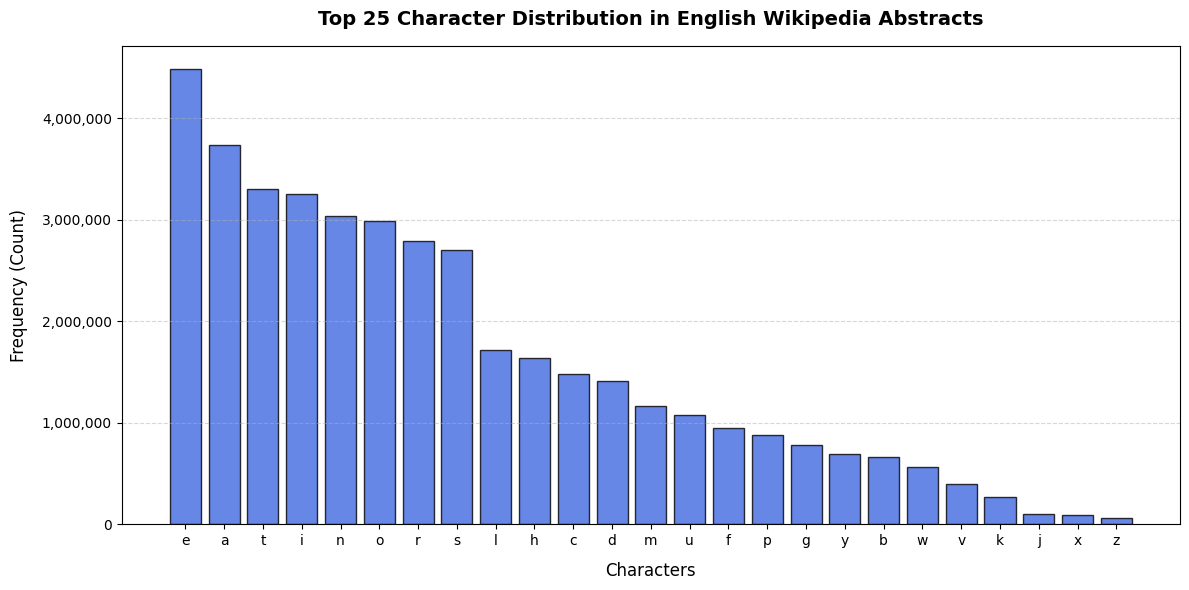

In [16]:
import nltk

# Get frequency distribution of alphabetic characters
fdist = nltk.FreqDist(ch.lower() for ch in text1 if ch.isalpha())

# Plot the distribution using the reusable helper function
plot_frequency_distribution(
    fdist, 
    title="Top 25 Character Distribution in English Wikipedia Abstracts", 
    xlabel="Characters", 
    ylabel="Frequency (Count)", 
    limit=25, 
    color='royalblue'
)

# Task 6: Word Distribution (with Stopwords)

Top 20 most common words (with stopwords):
[('the', 541103), ('of', 351345), ('a', 280104), ('in', 238731), ('and', 210275), ('is', 200913), ('to', 154956), ('was', 97061), ('or', 78818), ('by', 75524), ('as', 65970), ('an', 58589), ('for', 55305), ('may', 48437), ('it', 47092), ('from', 44679), ('that', 43809), ('refer', 41892), ('on', 41304), ('s', 37902)]


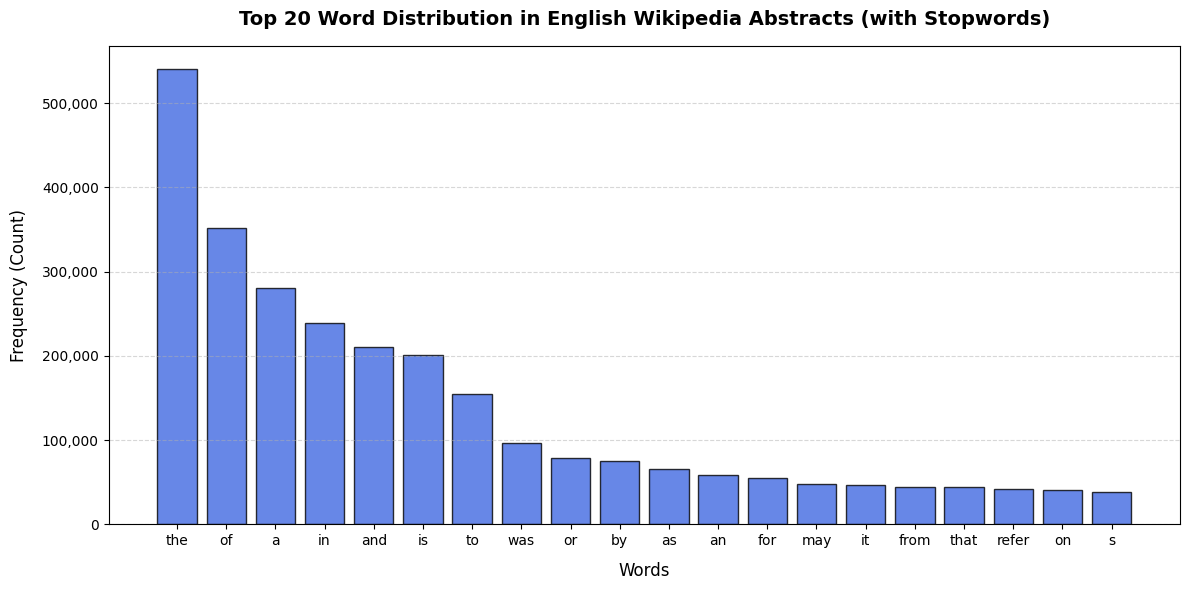

In [17]:
# Tokenize and lowercase all alphabetic words from the corpus
all_words = [w.lower() for w in enwiki_corpus.words() if w.isalpha()]

# Calculate frequency distribution
word_fdist = nltk.FreqDist(all_words)

# Print the 20 most common words
most_common_words = word_fdist.most_common(20)
print("Top 20 most common words (with stopwords):")
print(most_common_words)

# Plot the distribution using our reusable plotting function
plot_frequency_distribution(
    word_fdist, 
    title="Top 20 Word Distribution in English Wikipedia Abstracts (with Stopwords)", 
    xlabel="Words", 
    ylabel="Frequency (Count)", 
    limit=20, 
    color='royalblue'
)

# Prompt Library

> Take a look at the Task List. Write the first cell of midterm_notebook.ipynb.
> 
> Name: "Timo Rolf"
> Matriculation Number: 22308350
> I want to choose the german wikipedia corpus (find the link).
> 
> Leave the solution blank for now.

> Add a Download cell below. It should be optional, so add a global Variable DOWNLOAD = False to the top. Only if this variable is set to True, download the corpus. Check that it is not already downloaded in this case!

> I received more information. Actually, I should use the english version. Adjust the notebook accordingly

> add a check cell to verify the size of the corpus in MB

> Make sure the corpus_url is correct! Make a browser search to verify.
> 
> Failed to download enwiki-latest-abstract1.xml.gz: HTTP Error 404: Not Found

> Adjust the code cell such that it opens the compressed gzipped file and uses the XMLcorpusReader to print a bit of text and make the future tasks easier

> Combine the unzip code into the download code cell. Add a Note to the first .md cell to instruct the professor if he doesn't want to use the Download cell, that he has to extract the file himself. The size verification cell should look at the unzipped file. After unzipping, automatically delete the zipped file as it is not needed anymore. Get rid of the os.path.exists in the XMLCorpusReader cell as this is already present from the size verification cell above.

> I saw you reverted back to the old corpus_url. I changed it to:
> 
> Using a stable, archived URL since latest abstracts are discontinued<br>
> corpus_url = 'https://archive.org/download/enwiki-20210820/enwiki-20210820-abstract1.xml.gz'<br>
> corpus_file = 'enwiki-20210820-abstract1.xml.gz'
> 
> 
> because as of **February 2025**, the Wikimedia Foundation officially discontinued the generation of the page abstract dumps. I switched to an archived version which is still legal to download and use

> Write a cell for task 4, calculating the lexical richness. For this, use the following code from nltk-corpora.ipynb notebook. Keep the cell minimal, but add a clear heading that this is not preprocesing anymore and actually task 4.
> 
> For a description of the difference between the functions `word()` and `word_tokenize()`: see https://stackoverflow.com/questions/46965585/nltk-words-vs-word-tokenize
> 
> The NLTK comes with several tokenizers, see the nltk.tokenize package at https://www.nltk.org/api/nltk.tokenize.html .
> 
> The number of words and how often they are used is a measure of the lexical richness of the text. 
> 
> ~~~~
> text1 = corp1.raw() # Corp1 was read with PlaintextCorpusReader
> 
> len(set(text1)) / len(text1)
> ~~~~

> Implement the character distribution. Use a clear heading with task 5 and stick to the implementation shown earlier in the tutorial notebook nltk-corpora.ipynb

> My file is unsaved currently and I don#t see the updates yet. I get the following message:
> 
> Failed to save 'midterm_notebook.ipynb': The content of the file is newer. Do you want to overwrite the file with your changes?
> 
> What should I do?

> As you can see from the notebook, I got the folowing warning quite a lot of time:
> 
> "UserWarning: Glyph 22781 (\N{CJK UNIFIED IDEOGRAPH-58FD}) missing from font(s) DejaVu Sans."
> 
> Also the graph is totally unreadable. Only display the 25 most common ones! Is it also possible to label the axes in a more descriptive way?

> Actually write out the numbers on the y axis, so no "1e6"

> since we need something like this again for future tasks, write a python function that we can reuse later on

> Go ahead with task 6. Reuse our new helper function!